In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA
from scipy.stats import norm
from datetime import datetime

from src.cbr_parser import CBRParser
from src.data_handler import DataHandler
from src.classical_models import ClassicModel
from src.testing_framework import UnifiedTestingFramework

In [26]:
TENOR_YEARS = {'1W': 7/365, '2W': 14/365, '1M': 30/365, '2M': 60/365, '3M': 90/365, '6M': 180/365, '1Y': 1.0, '2Y': 2.0}
maturities = list(TENOR_YEARS.values())[:-1]
tenors = list(TENOR_YEARS.keys())

ROISFIX = DataHandler.from_excel('data/roisfix.xlsx').clean()

### Explanatory Data Analysis

In [3]:
ROISFIX.descriptive_statistics(caption='ROISfix Descriptive Statistics', style=True)

,1W,2W,1M,2M,3M,6M,1Y,2Y
count,3708.0000,3708.0000,3708.0000,3708.0000,3708.0000,3708.0000,2499.0000,995.0000
mean,9.4823,9.5115,9.5552,9.5882,9.6098,9.6587,10.5029,13.7736
std,4.6535,4.6731,4.7193,4.7321,4.7323,4.7512,4.9774,4.1968
min,3.0800,3.0900,3.1800,3.2400,3.3000,3.4900,4.1400,8.3500
25%,6.1000,6.1000,6.0900,6.0800,6.0875,6.1000,7.1500,9.2450
50%,7.6300,7.6300,7.6700,7.7400,7.8200,7.9800,8.5000,13.5900
75%,11.2325,11.2200,11.2200,11.2000,11.1725,11.0700,14.4000,16.7550
max,22.8500,23.9200,25.1500,25.0600,25.1800,26.7100,26.5300,25.2000
skew,1.0596,1.0733,1.1137,1.1375,1.1624,1.2435,1.1352,0.5793
kurtosis,0.1351,0.1757,0.3206,0.4125,0.5123,0.8565,0.5426,-0.3301


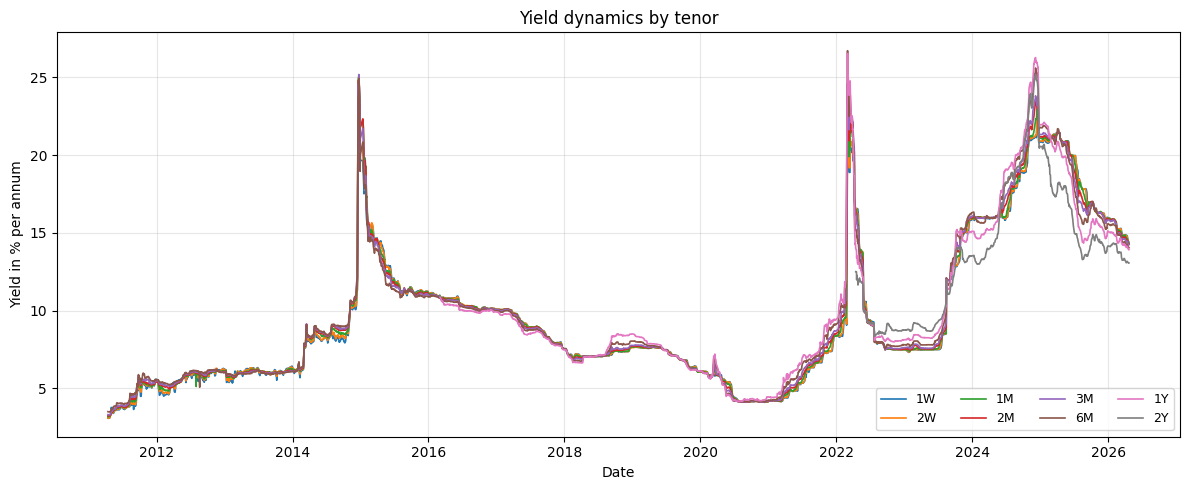

In [4]:
ROISFIX.plot_time_series()

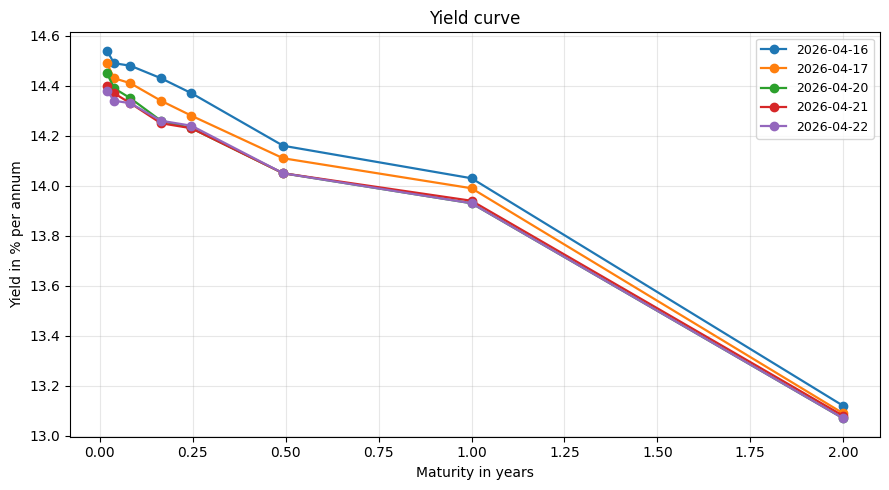

In [5]:
ROISFIX.plot_yield_curves(dates=None)

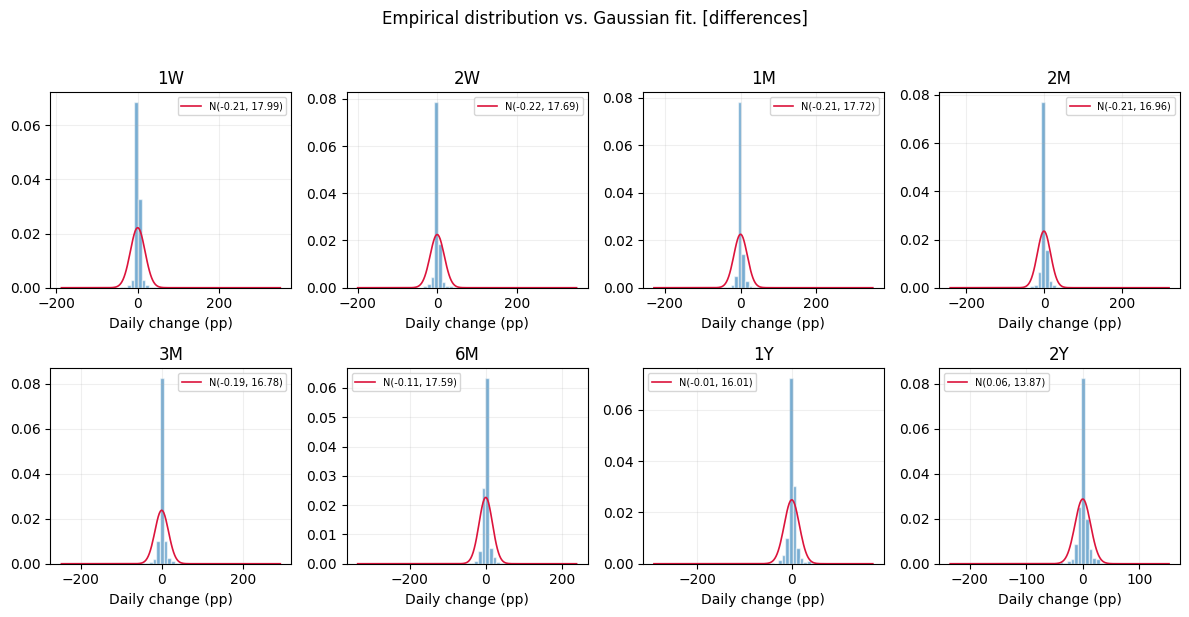

In [6]:
ROISFIX.plot_distributions(which='differences')

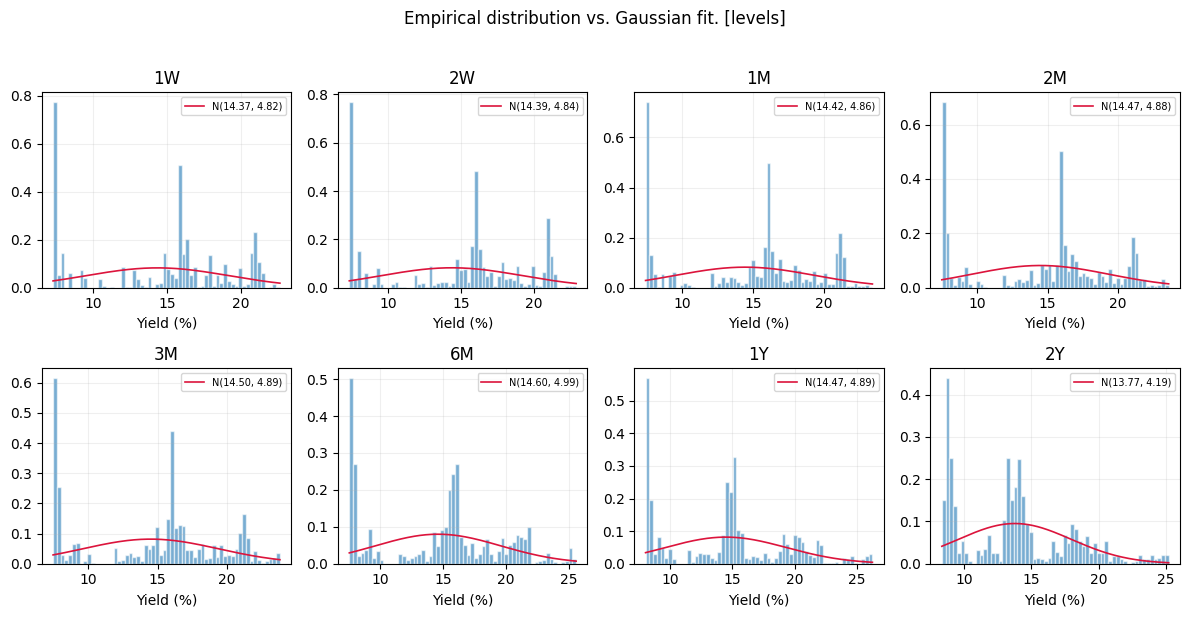

In [7]:
ROISFIX.plot_distributions(which='levels')

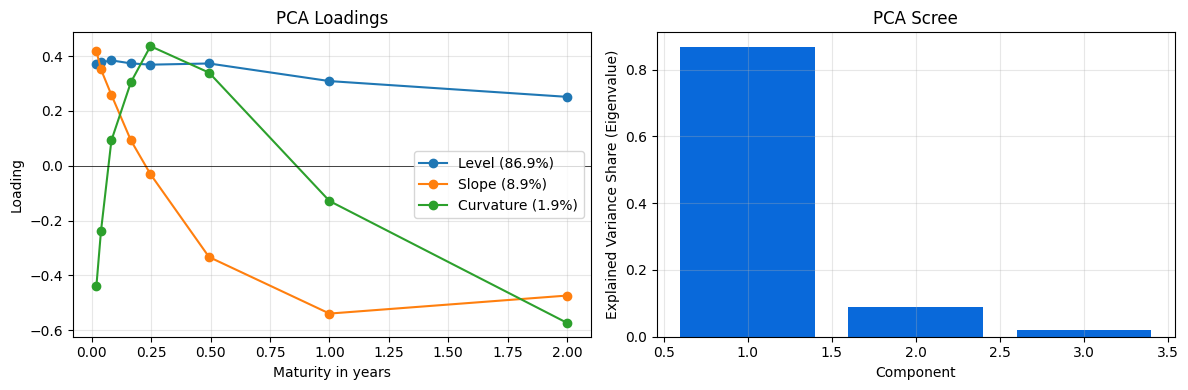

In [8]:
ROISFIX.plot_pca_decomposition(n_components=3)

### Classical Models: Calibration

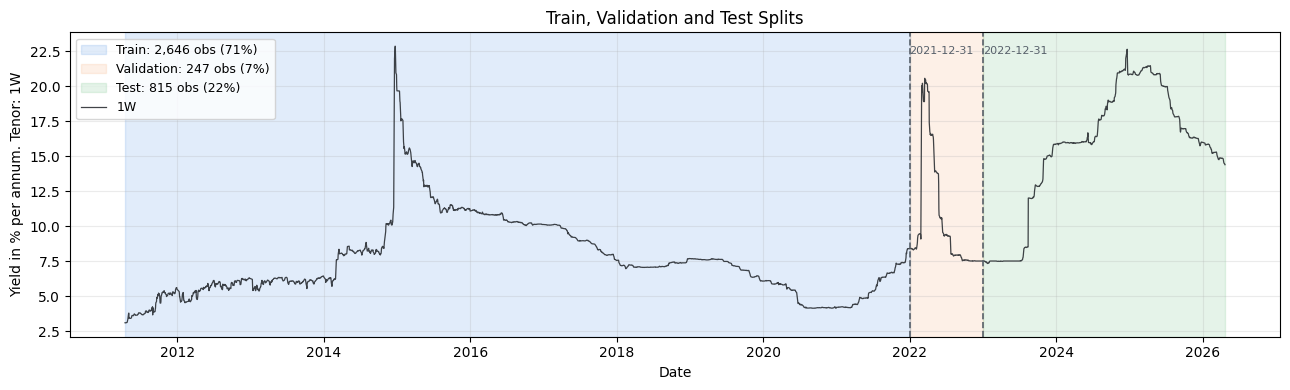

In [9]:
train, val, test = ROISFIX.train_val_test_split(train_end='2021-12-31', val_end='2022-12-31', plot=True)
train = train.drop(columns=['2Y'])

In [10]:
vasicek = ClassicModel('vasicek').calibrate(train['1M']) # fits one tenor
vasicek.display_params()

kappa,0.489338
theta,8.5964
sigma,2.4638
r0,8.3700


In [11]:
hw = ClassicModel('hull-white').calibrate(train['1M']) # fits one tenor
hw.display_params()

a,0.489338
sigma,2.4638
theta_t (summary),"len=2646, mean=4.2060, std=34.5151"
r0,8.3700


In [12]:
ns = ClassicModel('nelson-siegel').calibrate(train.iloc[-1], taus=maturities) # fits the last row
ns.display_params()

beta0,-73.0905
beta1,81.3730
beta2,100.0000
lambda,0.213485


In [13]:
dns = ClassicModel('dns').calibrate(train, taus=maturities) # fits whole matrix
dns.display_params()

lambda,0.730800
mu,"[0.1981, -0.2010, -0.2069]"
A (summary),"len=9, mean=0.3337, std=0.4635"
Sigma (summary),"len=9, mean=0.2214, std=1.3811"
beta_last,"[6.6882, 1.5927, 7.1852]"
r0,8.3800


### Classical Models: Simulation

In [48]:
NPATHS = 10_000 # num. of simulations
DT = 1/(250 * 100)
T = 1/250 # for simulation of 1 year, 250 business days (M)

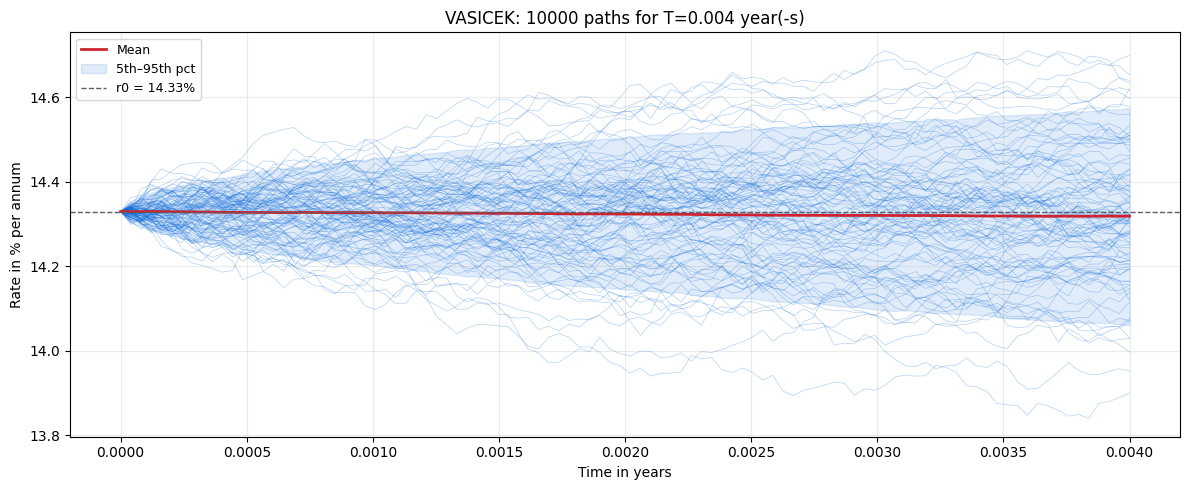

In [51]:
paths_vasicek = vasicek.simulate(T=T, dt=DT, n_paths=NPATHS, n_show=100)

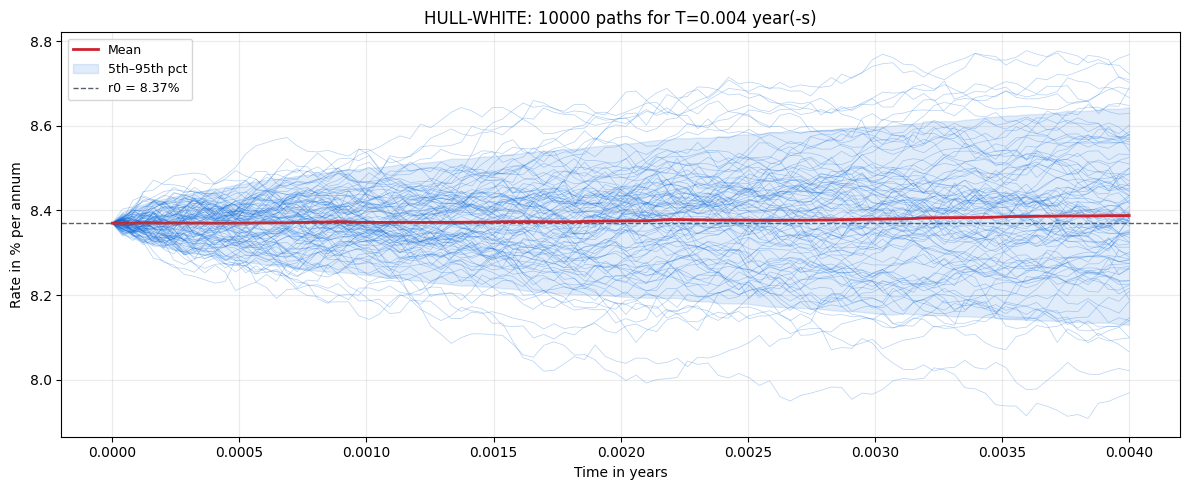

In [52]:
paths_hw = hw.simulate(T=T, dt=DT, n_paths=NPATHS, n_show=100)

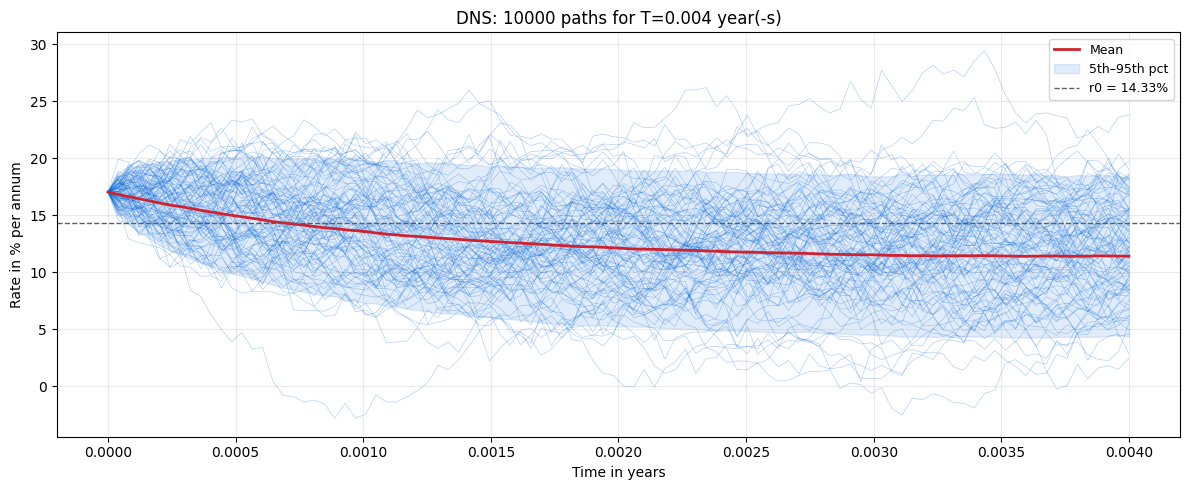

In [53]:
paths_dns = dns.simulate(T=T, dt=DT, n_paths=NPATHS, n_show=100)

### Classical Models: Backtest

In [27]:
from src.backtest import kupiec_pof, christoffersen

CL = [0.05, 0.01]
DT = 1/(250 * 5) # 1/5 of day to have a simulation inside a day
T = 1/250 # 1 business day

full_series = ROISFIX.yield_matrix(dropna=False)['1M']
test_dates = test.index.tolist()

tenors_dns = list(train.columns)
full_matrix = ROISFIX.yield_matrix(dropna=False)[tenors_dns]

bt = {name: {level: [] for level in CL} for name in ['vasicek', 'hull-white']}

print(f'Test period: from {test_dates[0].date()} to {test_dates[-1].date()}, Overall: {len(test_dates)} observations')

Test period: from 2023-01-09 to 2026-04-22, Overall: 815 observations


In [28]:
for idx, t in enumerate(test_dates[:-1]):
    next_t = test_dates[idx + 1]
    r_now = full_series.loc[t] # rate today
    r_tom = full_series.loc[next_t] # rate tomorrow

    if pd.isna(r_now) or pd.isna(r_tom):
        continue

    # Vasicek — только r0
    vasicek.params['r0'] = r_now
    sim_df = vasicek.simulate(T=T, dt=DT, n_paths=NPATHS, plot=False, seed=idx)
    last_row = sim_df.iloc[-1].values
    for conf_level in CL:
        quantile = np.quantile(last_row, conf_level)
        bt['vasicek'][conf_level].append(int(r_tom < quantile))

    # Hull-White 
    hw_window = 250 * 2 # 2 years
    calib_hw = full_series.loc[:t].dropna().tail(hw_window) # 2 year window of rate
    hw_local = ClassicModel('hull-white').calibrate(calib_hw, dt=1/250) # calibration on look-back window for theta_t parameter
    
    hw_local.params['r0'] = r_now # starting rate
    sim_df = hw_local.simulate(T=T, dt=DT, n_paths=NPATHS, plot=False, seed=idx)
    last_row = sim_df.iloc[-1].values
    for conf_level in CL:
        quantile = np.quantile(last_row, conf_level)
        bt['hull-white'][conf_level].append(int(r_tom < quantile))

In [42]:
idx_1m = tenors.index('1M')
hits_dns = {conf_level: [] for conf_level in CL}

for idx, t in enumerate(test_dates[:-1]):
    next_t = test_dates[idx + 1]
    row_now  = full_matrix.loc[t]
    row_tom = full_matrix.loc[next_t, '1M']

    if row_now.isna().any() or pd.isna(row_tom):
        continue

    dns.params['r0'] = row_now['1M']
    dns.params['beta_last'] = dns.params['beta_last'].copy() # save the original one

    curves = dns.simulate_curves(taus=maturities, T=T, dt=DT, n_paths=NPATHS, seed=idx)
    last_row = curves[-1, :, idx_1m]

    for conf_level in CL:
        quantile = np.quantile(last_row, conf_level)
        hits_dns[conf_level].append(int(row_tom < quantile))

In [43]:
df_ablation = []

for model in ['vasicek', 'hull-white']:
    row = {'model': model}
    for conf_level in CL:
        hits = bt[model][conf_level]
        level = f'{int(conf_level*100)}%'
        row[f'Hits at {level}'] = round(np.mean(hits), 3)
        row[f'Kupiec at {level}'] = round(kupiec_pof(hits, conf_level), 3)
        row[f'CC at {level}'] = round(christoffersen(hits, conf_level), 3)
    df_ablation.append(row)

row = {'model': 'dns'}
for conf_level in CL:
    hits = hits_dns[conf_level]
    level = f'{int(conf_level*100)}%'
    row[f'Hits at {level}'] = round(np.mean(hits), 3)
    row[f'Kupiec at {level}'] = round(kupiec_pof(hits, conf_level), 3)
    row[f'CC at {level}'] = round(christoffersen(hits, conf_level), 3)
df_ablation.append(row)

pd.DataFrame(df_ablation).set_index('model')

,Hits at 5%,Kupiec at 5%,CC at 5%,Hits at 1%,Kupiec at 1%,CC at 1%
model,,,,,,
vasicek,0.006,0.0,0.804,0.005,0.105,0.842
hull-white,0.005,0.0,0.842,0.004,0.038,0.881
dns,0.170,0.0,0.000,0.107,0.000,0.000


In [44]:
kupiec_pof(hits_dns[0.05], conf_level)

3.046957798216915e-120